# Shared

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import torch.optim as optim
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Data Cleaning Pipeline

In [ ]:
#Constant
status = {'Normal' : 0, 'Anxiety' : 1, 'Depression' : 2, 'Suicidal' : 3}
seed = 42
stop_words = set(stopwords.words('english'))
tmp = list(filter(lambda x: x.endswith(("'t", "'nt")),stopwords.words('english'))) + ["can't"]
negate_aux = list(map(lambda x: x.replace("'", ""),tmp)) + list(map(lambda x: x[:-2], tmp))

In [ ]:
#Functions
def clean_text(text):
  # Lowercase
  text = text.lower()
  # Remove HTML
  text = re.sub(r'<.*?>', '', text)
  # Remove URLs
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  # Replace ' to empty char to reserve and normalize not word
  text = text.replace("'", "")
  # Remove Punctuation
  text = text.translate(str.maketrans('', '', string.punctuation))
  # Replace negate auxillary verb with not
  text = " ".join(['not' if word in negate_aux else word for word in text.split()])
  # Remove Stop word
  text = " ".join([word for word in str(text).split() if word not in stop_words or word == 'not'])
  # Remove numbers
  text = re.sub(r'\d+', '', text)
  # Lemmatization
  lemmatizer = WordNetLemmatizer()
  text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

  return text

In [ ]:
#Cleaning Pipeline
def cleaning_pipeline(df):
  df = df.drop("Unique_ID", axis = 1)
  df['status_id'] = df['status'].map(status)
  df = df.drop("status", axis = 1)
  df['text'] = df['text'].apply(clean_text)

  return df

In [ ]:
#Spliting
def data_label(df):
  return df['text'], df['status_id']

def split_data(df):
  x, y = data_label(df)
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=seed)
  return x_train, x_test, y_train, y_test

## Dataset for Dataloader

In [ ]:
#Dataloader class
class MentalHealthDataset(Dataset):
  def __init__(self, text, label, tokenizer, max_length = 128):
    self.text = text
    self.label = label
    self.tokenizer = tokenizer
    self.max_length = max_length
  def __len__(self):
    return len(self.text)
  def __getitem__(self, idx):
    text = str(self.text[idx])
    label = int(self.label[idx])
    encoding = self.tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=self.max_length,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Training

## Training loop

In [ ]:
def fine_tune_model(model, optimizer, n_epochs, train_loader, val_loader, device):
  best_val_loss = float('inf')
  for epoch in range(n_epochs):
    train_loss = 0
    val_loss = 0
    model.train()
    print("Training...")
    for batch in train_loader:
      optimizer.zero_grad()

      # Move batch to GPU/CPU
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['labels'].to(device)

      # Forward pass
      outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
      loss = outputs.loss
      train_loss += loss.item()

      # Backward pass
      loss.backward()
      optimizer.step()
    model.eval()
    print("Evaluating...")
    with torch.no_grad():
      for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

        # Accumulate the loss
        val_loss += outputs.loss.item()
    if (val_loss / len(x_test)) < best_val_loss:
      best_val_loss = val_loss / len(x_test)
      torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch} Training Loss: {train_loss / len(x_train)} Validation Loss: {val_loss / len(x_test)}")

## Main

In [ ]:
#Init data
df = pd.read_csv("mental_heath_unbanlanced.csv")
cleaned_df = cleaning_pipeline(df)
x_train, x_test, y_train, y_test = split_data(cleaned_df)

In [ ]:
#Create dataloader
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train_ds = MentalHealthDataset(x_train.tolist(), y_train.tolist(), tokenizer)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

val_ds = MentalHealthDataset(x_test.tolist(), y_test.tolist(), tokenizer)
val_loader = DataLoader(val_ds, batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
#Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Training
fine_tune_model(model, optimizer, 5, train_loader, val_loader, device)

Training...


# Inference

## Inference loop

In [ ]:
def inference(model, test_loader, device):
  all_predictions = []
  with torch.no_grad():
      for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = best_model(input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_predictions.extend(preds)
  return all_predictions

## Main

In [ ]:
#Load model and saved weight
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4).to(device)
best_model.load_state_dict(torch.load('best_model.pth'))
best_model.eval()

In [ ]:
test_df = pd.read_csv("mental_health_combined_test.csv")
test_df = cleaning_pipeline(test_df)
test_x, text_y = data_label(test_df)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
test_ds = MentalHealthDataset(test_x.tolist(), test_y.tolist(), tokenizer)
test_loader = DataLoader(test_ds, batch_size=16)

In [ ]:
test_df['pred'] = inference(best_model, test_loader, device)

In [ ]:
test_df.to_csv("test_predictions.csv", index=False)

## Evaluate

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
labels = test_df['status_id'].tolist()
predictions = test_df['pred'].tolist()

In [ ]:
# Metrics
acc = accuracy_score(labels, predictions)
m_recall = recall_score(labels, predictions, average='macro')
m_f1 = f1_score(labels, predictions, average='macro')
print("Accuracy :\t", acc)
print("Macro Recall :\t", m_recall)
print("Macro F1 :\t", m_f1)

Accuracy :	 0.8810483870967742
Macro Recall :	 0.8810483870967742
Macro F1 :	 0.8778052213135165


In [ ]:
f1_score(labels, predictions, average=None)

array([0.94026975, 0.84773663, 0.79039301, 0.9328215 ])

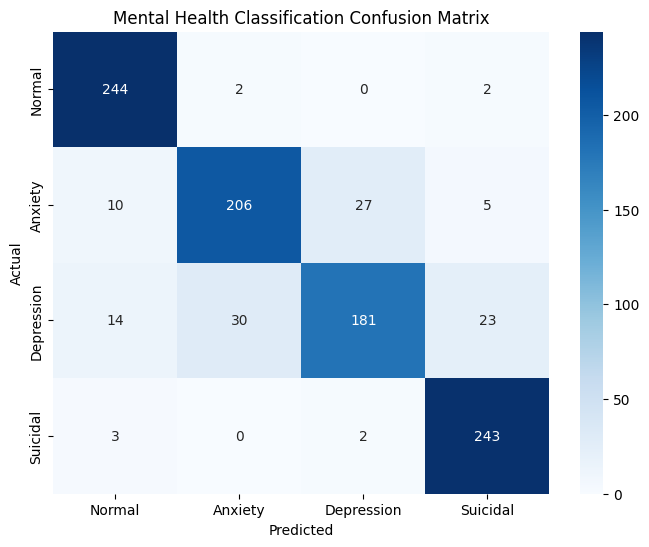

In [ ]:
# Confusion Matrix
pred = list(map(lambda x: int(x), predictions))
cm = confusion_matrix(labels, pred, labels=[0,1,2,3])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=status, yticklabels=status)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Mental Health Classification Confusion Matrix')
plt.show()